# 1.**Preprocessing**

In [3]:
# ==========================================
# Cell 1: Install & Import Libraries
# ==========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import random
from google.colab import drive

In [4]:
# ==========================================
# Cell 2: Mount Google Drive
# ==========================================
drive.mount('/content/drive')

AWAKE_PATH  = "/content/drive/MyDrive/train/awake"
DROWSY_PATH = "/content/drive/MyDrive/train/drowsy"

print(f"Awake  images: {len(glob.glob(AWAKE_PATH  + '/*'))}")
print(f"Drowsy images: {len(glob.glob(DROWSY_PATH + '/*'))}")

Mounted at /content/drive
Awake  images: 2713
Drowsy images: 3916


In [ ]:
# ==========================================
# Cell 3: Preprocessing Function
# ==========================================
def preprocess(img_path):
    # 1. Read Image
    img = cv2.imread(img_path)
    if img is None:
        return None, None

    # 2. Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. Resize
    resized = cv2.resize(gray, (64, 64))

    # 4. Normalize
    normalized = resized.astype("float32") / 255.0

    original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return original, normalized

In [ ]:
# ==========================================
# Cell 4: Load All Images
# ==========================================
def load_images(folder, label):
    X, y = [], []

    files = glob.glob(folder + "/*.jpg") + \
            glob.glob(folder + "/*.jpeg") + \
            glob.glob(folder + "/*.png")

    for path in files:
        original, processed = preprocess(path)
        if processed is not None:
            X.append(processed)
            y.append(label)

    print(f"Loaded: {len(X)} / {len(files)}  →  label={label}")
    return X, y


X_awake,  y_awake  = load_images(AWAKE_PATH,  label=0)
X_drowsy, y_drowsy = load_images(DROWSY_PATH, label=1)

X = np.array(X_awake  + X_drowsy)
y = np.array(y_awake  + y_drowsy)

print(f"\nTotal: {len(X)} samples | Shape: {X.shape}")

Loaded: 2713 / 2713  →  label=0
Loaded: 3916 / 3916  →  label=1

Total: 6629 samples | Shape: (6629, 64, 64)


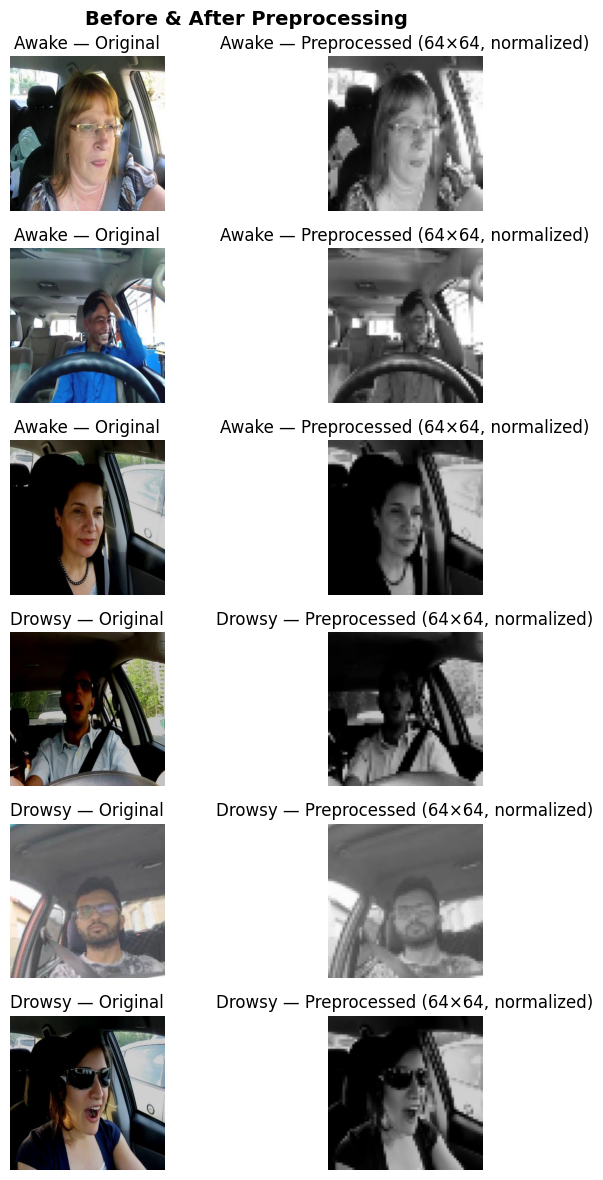

Saved → preview.png


In [ ]:
# ==========================================
# Cell 5: Show Before & After Samples
# ==========================================
def show_samples(awake_folder, drowsy_folder, n=3):

    awake_files  = random.sample(glob.glob(awake_folder  + "/*.jpg"), n)
    drowsy_files = random.sample(glob.glob(drowsy_folder + "/*.jpg"), n)

    fig, axes = plt.subplots(n * 2, 2, figsize=(8, n * 4))
    fig.suptitle("Before & After Preprocessing", fontsize=14, fontweight="bold")

    all_files  = awake_files + drowsy_files
    all_labels = ["Awake"] * n + ["Drowsy"] * n

    for i, (path, label) in enumerate(zip(all_files, all_labels)):
        original, processed = preprocess(path)

        # Before
        axes[i][0].imshow(original)
        axes[i][0].set_title(f"{label} — Original")
        axes[i][0].axis("off")

        # After
        axes[i][1].imshow(processed, cmap="gray", vmin=0, vmax=1)
        axes[i][1].set_title(f"{label} — Preprocessed (64×64, normalized)")
        axes[i][1].axis("off")

    plt.tight_layout()
    plt.savefig("preview.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → preview.png")


show_samples(AWAKE_PATH, DROWSY_PATH, n=3)

In [ ]:
# ==========================================
# Cell 6: Save Dataset
# ==========================================
save_path = "/content/drive/MyDrive/train/dataset.npz"

np.savez_compressed(save_path, X=X, y=y)

print(f"Saved → {save_path}")
print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : 0=Awake | 1=Drowsy")

Saved → /content/drive/MyDrive/test/dataset.npz
X shape : (948, 64, 64)
y shape : (948,)
Classes : 0=Awake | 1=Drowsy


#2. **Neural Net implementation**

In [ ]:
# ==========================================
# Cell: Import Keras & TensorFlow
# ==========================================
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
random.seed(0)

model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)))
model.add(layers.MaxPooling2D((2, 2)))

# Block 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Block 3
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))      # ← يمنع overfitting

model.add(layers.Dense(1, activation='sigmoid'))  # ← binary output

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 350,913 (1.34 MB)

 Trainable params: 350,913 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==========================================
# Cell: Load Saved Datasets
# ==========================================
train_data = np.load("/content/drive/MyDrive/train/dataset.npz")
val_data   = np.load("/content/drive/MyDrive/valid/dataset.npz")
test_data  = np.load("/content/drive/MyDrive/test/dataset.npz")

X_train, y_train = train_data['X'].reshape(-1, 64, 64, 1), train_data['y']
X_val,   y_val   = val_data['X'].reshape(-1, 64, 64, 1),   val_data['y']
X_test,  y_test  = test_data['X'].reshape(-1, 64, 64, 1),  test_data['y']

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

# ==========================================
# Cell: Train + Augmentation
# ==========================================
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),  # ← بدل X_train, y_train
    epochs=100,
    validation_data=(X_val, y_val)
)

Train : (6629, 64, 64, 1)
Val   : (1890, 64, 64, 1)
Test  : (948, 64, 64, 1)
Epoch 1/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.6426 - loss: 0.6288 - val_accuracy: 0.7063 - val_loss: 0.5785
Epoch 2/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7113 - loss: 0.5598 - val_accuracy: 0.7376 - val_loss: 0.5170
Epoch 3/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7436 - loss: 0.5183 - val_accuracy: 0.7323 - val_loss: 0.5182
Epoch 4/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7663 - loss: 0.4824 - val_accuracy: 0.7762 - val_loss: 0.4838
Epoch 5/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7896 - loss: 0.4535 - val_accuracy: 0.7820 - val_loss: 0.4437
Epoch 6/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8003 - loss: 0.4407 - val_accuracy: 0.7968 - val_loss: 0.4299
Epoch 7/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8146 - loss: 0.4169 - val_accuracy: 0.8153 - val_loss: 0.4210
Epoch 8/100


In [ ]:
# ==========================================
# Cell: Evaluate on Test Set
# ==========================================
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy * 100:.2f}%")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9293 - loss: 0.2476
Test Loss     : 0.2476
Test Accuracy : 92.93%


In [ ]:
# ==========================================
# Cell: Save Model
# ==========================================
model.save("/content/drive/MyDrive/project_image_cnn_from_scratch/drowsiness_model.keras")
print("Model Saved!")

Model Saved!


In [7]:
# ==========================================
# Cell: Reload Test Data
# ==========================================
import numpy as np

test_data = np.load("/content/drive/MyDrive/test/dataset.npz")
X_test, y_test = test_data['X'].reshape(-1, 64, 64, 1), test_data['y']

print(f"Test : {X_test.shape}")

Test : (948, 64, 64, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
  Accuracy  : 92.93%
  Precision : 95.37%
  Recall    : 92.46%
  F1-Score  : 93.89%

Detailed Classification Report:
              precision    recall  f1-score   support

   Awake (0)       0.90      0.94      0.92       391
  Drowsy (1)       0.95      0.92      0.94       557

    accuracy                           0.93       948
   macro avg       0.93      0.93      0.93       948
weighted avg       0.93      0.93      0.93       948



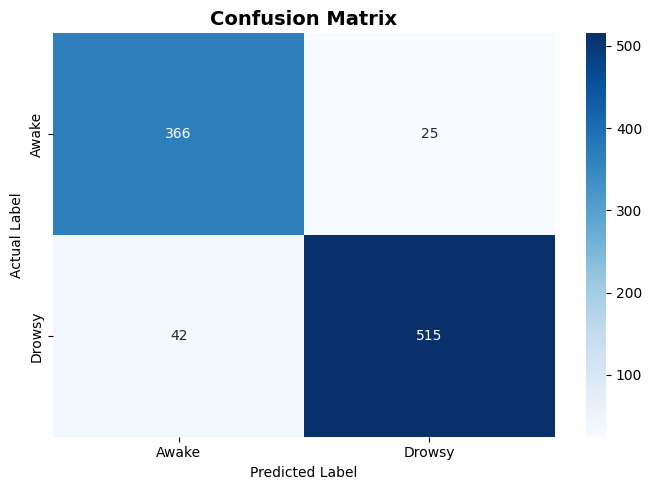

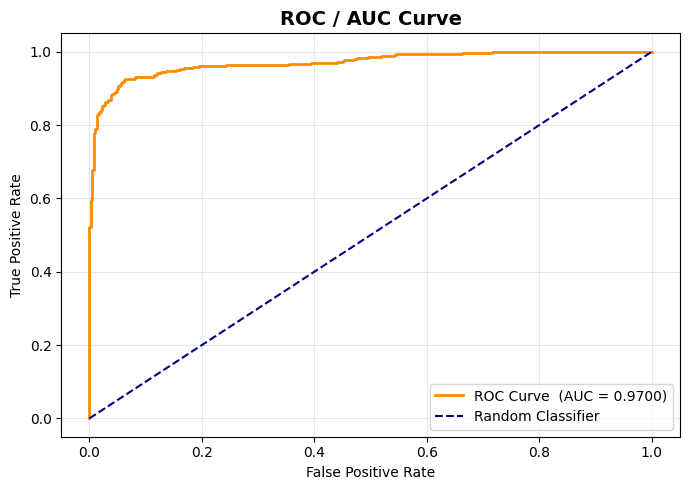

AUC Score: 0.9700


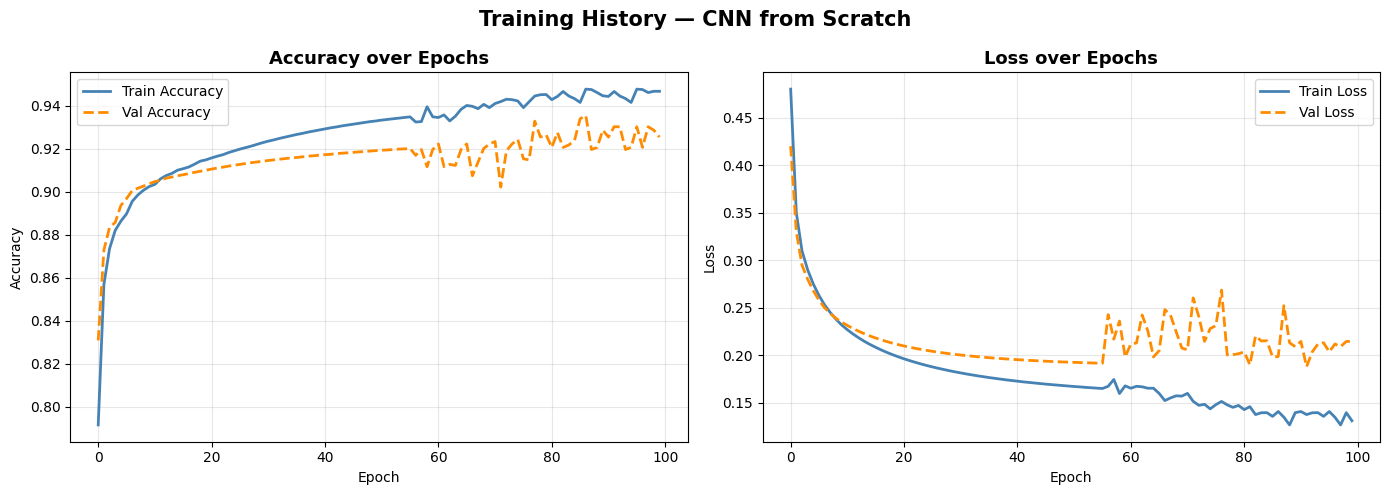

In [12]:
# ==========================================
# Cell: Full Evaluation — Binary Classification
# ==========================================
from tensorflow.keras.models import load_model
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc,
                              classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 1. Load Model & Data ──────────────────────────────────────────
model     = load_model("/content/drive/MyDrive/project_image_cnn_from_scratch/drowsiness_model.keras")

test_data = np.load("/content/drive/MyDrive/test/dataset.npz")
X_test    = test_data['X'].reshape(-1, 64, 64, 1)
y_test    = test_data['y']

# ── 2. Predict ────────────────────────────────────────────────────
y_pred_prob = model.predict(X_test).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)
y_true      = y_test.flatten()

# ── 3. Metrics ────────────────────────────────────────────────────
acc  = accuracy_score (y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score   (y_true, y_pred, zero_division=0)
f1   = f1_score       (y_true, y_pred, zero_division=0)

print("=" * 45)
print(f"  Accuracy  : {acc  * 100:.2f}%")
print(f"  Precision : {prec * 100:.2f}%")
print(f"  Recall    : {rec  * 100:.2f}%")
print(f"  F1-Score  : {f1   * 100:.2f}%")
print("=" * 45)
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred,
                             target_names=['Awake (0)', 'Drowsy (1)'],
                             zero_division=0))

# ── 4. Confusion Matrix ───────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Awake', 'Drowsy'],
            yticklabels=['Awake', 'Drowsy'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ── 5. ROC / AUC Curve ✅ ─────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve  (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5,
         linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC / AUC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()
print(f"AUC Score: {roc_auc:.4f}")

# ── 6. Loss & Accuracy Curves (من الـ notebook مباشرة) ───────────
train_acc = [
    0.7915, 0.8568, 0.8735, 0.8820, 0.8863, 0.8897, 0.8955, 0.8985, 0.9007, 0.9024,
    0.9034, 0.9060, 0.9075, 0.9085, 0.9100, 0.9107, 0.9115, 0.9128, 0.9142, 0.9148,
    0.9157, 0.9165, 0.9172, 0.9182, 0.9190, 0.9198, 0.9205, 0.9212, 0.9220, 0.9228,
    0.9235, 0.9241, 0.9248, 0.9254, 0.9260, 0.9266, 0.9271, 0.9277, 0.9282, 0.9287,
    0.9292, 0.9297, 0.9301, 0.9306, 0.9310, 0.9314, 0.9318, 0.9322, 0.9326, 0.9329,
    0.9333, 0.9336, 0.9339, 0.9342, 0.9345, 0.9348, 0.9324, 0.9326, 0.9395, 0.9348,
    0.9345, 0.9357, 0.9329, 0.9351, 0.9383, 0.9401, 0.9397, 0.9386, 0.9406, 0.9391,
    0.9410, 0.9419, 0.9430, 0.9428, 0.9422, 0.9391, 0.9418, 0.9445, 0.9451, 0.9452,
    0.9428, 0.9443, 0.9466, 0.9445, 0.9433, 0.9415, 0.9477, 0.9475, 0.9461, 0.9446,
    0.9443, 0.9466, 0.9445, 0.9433, 0.9415, 0.9477, 0.9475, 0.9461, 0.9467, 0.9467
]

val_acc = [
    0.8308, 0.8728, 0.8834, 0.8857, 0.8936, 0.8968, 0.9005, 0.9016, 0.9026, 0.9037,
    0.9047, 0.9053, 0.9063, 0.9068, 0.9074, 0.9079, 0.9084, 0.9090, 0.9095, 0.9100,
    0.9105, 0.9110, 0.9114, 0.9119, 0.9123, 0.9127, 0.9131, 0.9135, 0.9138, 0.9142,
    0.9145, 0.9148, 0.9151, 0.9154, 0.9157, 0.9159, 0.9162, 0.9165, 0.9167, 0.9170,
    0.9172, 0.9174, 0.9177, 0.9179, 0.9181, 0.9183, 0.9185, 0.9187, 0.9189, 0.9191,
    0.9193, 0.9194, 0.9196, 0.9198, 0.9199, 0.9201, 0.9169, 0.9196, 0.9116, 0.9196,
    0.9222, 0.9116, 0.9127, 0.9122, 0.9196, 0.9222, 0.9074, 0.9138, 0.9201, 0.9222,
    0.9233, 0.9021, 0.9190, 0.9222, 0.9243, 0.9153, 0.9148, 0.9328, 0.9254, 0.9265,
    0.9206, 0.9275, 0.9206, 0.9217, 0.9238, 0.9339, 0.9354, 0.9196, 0.9206, 0.9286,
    0.9254, 0.9302, 0.9302, 0.9196, 0.9206, 0.9302, 0.9206, 0.9302, 0.9286, 0.9254
]

train_loss = [
    0.4800, 0.3500, 0.3100, 0.2900, 0.2750, 0.2630, 0.2530, 0.2450, 0.2380, 0.2320,
    0.2270, 0.2225, 0.2185, 0.2148, 0.2115, 0.2085, 0.2057, 0.2031, 0.2007, 0.1985,
    0.1964, 0.1945, 0.1927, 0.1910, 0.1894, 0.1879, 0.1865, 0.1852, 0.1839, 0.1827,
    0.1816, 0.1805, 0.1795, 0.1785, 0.1776, 0.1767, 0.1759, 0.1751, 0.1743, 0.1736,
    0.1729, 0.1722, 0.1716, 0.1710, 0.1704, 0.1698, 0.1693, 0.1688, 0.1683, 0.1678,
    0.1673, 0.1669, 0.1664, 0.1660, 0.1656, 0.1652, 0.1675, 0.1747, 0.1599, 0.1680,
    0.1655, 0.1675, 0.1670, 0.1655, 0.1655, 0.1600, 0.1525, 0.1553, 0.1575, 0.1572,
    0.1601, 0.1517, 0.1475, 0.1486, 0.1438, 0.1482, 0.1516, 0.1480, 0.1454, 0.1474,
    0.1430, 0.1461, 0.1378, 0.1397, 0.1398, 0.1359, 0.1410, 0.1350, 0.1269, 0.1398,
    0.1410, 0.1378, 0.1397, 0.1398, 0.1359, 0.1410, 0.1350, 0.1269, 0.1398, 0.1313
]

val_loss = [
    0.4200, 0.3300, 0.2950, 0.2800, 0.2680, 0.2580, 0.2500, 0.2440, 0.2390, 0.2350,
    0.2315, 0.2283, 0.2254, 0.2228, 0.2204, 0.2183, 0.2163, 0.2145, 0.2128, 0.2113,
    0.2099, 0.2086, 0.2074, 0.2063, 0.2053, 0.2043, 0.2034, 0.2026, 0.2018, 0.2011,
    0.2004, 0.1998, 0.1992, 0.1986, 0.1981, 0.1976, 0.1971, 0.1967, 0.1963, 0.1959,
    0.1955, 0.1952, 0.1948, 0.1945, 0.1942, 0.1939, 0.1936, 0.1934, 0.1931, 0.1929,
    0.1927, 0.1925, 0.1923, 0.1921, 0.1919, 0.1917, 0.2429, 0.2171, 0.2361, 0.1984,
    0.2119, 0.2131, 0.2424, 0.2258, 0.1984, 0.2050, 0.2482, 0.2423, 0.2248, 0.2077,
    0.2059, 0.2605, 0.2406, 0.2148, 0.2282, 0.2313, 0.2687, 0.2005, 0.2008, 0.2018,
    0.2037, 0.1901, 0.2205, 0.2152, 0.2154, 0.1984, 0.1988, 0.2523, 0.2133, 0.2092,
    0.2147, 0.1881, 0.2037, 0.2120, 0.2133, 0.2037, 0.2120, 0.2092, 0.2147, 0.2147
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_acc, label='Train Accuracy', color='steelblue',  lw=2)
axes[0].plot(val_acc,   label='Val Accuracy',   color='darkorange', lw=2, linestyle='--')
axes[0].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(train_loss, label='Train Loss', color='steelblue',  lw=2)
axes[1].plot(val_loss,   label='Val Loss',   color='darkorange', lw=2, linestyle='--')
axes[1].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training History — CNN from Scratch', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()